In [10]:
import os
import glob
import netCDF4 as nc

path = "/scratch/alpine/battobrah@xsede.org/Rice_NMT_Snow/upper_colorado_test025/experiments/simulations/MSWX_3h_Snow_Project3_pp_upper_colorado_test025_11yrs_100hru_100bh_test_new_test_domain/"

output_dir = path + "postprocess/output_dir/"
files = sorted(glob.glob(output_dir + "*.nc"))

test_file = files[0]

print("Test file:", test_file)

with nc.Dataset(test_file) as fp:

    print("\nDimensions:")
    for name, dim in fp.dimensions.items():
        print(name, len(dim))

    print("\nVariables:")
    for name, var in fp.variables.items():
        print(name, var.shape, var.dimensions)

    print("\nSMC details:")
    smc = fp.variables["smc"]
    print("smc shape:", smc.shape)
    print("smc dimensions:", smc.dimensions)

    if hasattr(smc, "units"):
        print("smc units:", smc.units)

    if hasattr(smc, "long_name"):
        print("smc long_name:", smc.long_name)

Test file: /scratch/alpine/battobrah@xsede.org/Rice_NMT_Snow/upper_colorado_test025/experiments/simulations/MSWX_3h_Snow_Project3_pp_upper_colorado_test025_11yrs_100hru_100bh_test_new_test_domain/postprocess/output_dir/20140101.nc

Dimensions:
lon 200
lat 200
t 8

Variables:
lon (200,) ('lon',)
lat (200,) ('lat',)
t (8,) ('t',)
trad (8, 200, 200) ('t', 'lat', 'lon')
smc (8, 200, 200) ('t', 'lat', 'lon')
swe (8, 200, 200) ('t', 'lat', 'lon')
snowh (8, 200, 200) ('t', 'lat', 'lon')
fsno (8, 200, 200) ('t', 'lat', 'lon')

SMC details:
smc shape: (8, 200, 200)
smc dimensions: ('t', 'lat', 'lon')
smc long_name: smc


Number of files: 4015
First file: /scratch/alpine/battobrah@xsede.org/Rice_NMT_Snow/upper_colorado_test025/experiments/simulations/MSWX_3h_Snow_Project3_pp_upper_colorado_test025_11yrs_100hru_100bh_test_new_test_domain/postprocess/output_dir/20140101.nc
Last file: /scratch/alpine/battobrah@xsede.org/Rice_NMT_Snow/upper_colorado_test025/experiments/simulations/MSWX_3h_Snow_Project3_pp_upper_colorado_test025_11yrs_100hru_100bh_test_new_test_domain/postprocess/output_dir/20241228.nc

Creating plot for Winter
Winter files: 990
  Winter: 1/990 20140101.nc


/projects/battobrah@xsede.org/code-server/tmp/ipykernel_2160686/11307630.py:76: RuntimeWarning: Mean of empty slice
  data = np.nanmean(data, axis=0)


  Winter: 501/990 20190219.nc

Creating plot for Spring
Spring files: 1012
  Spring: 1/1012 20140301.nc
  Spring: 501/1012 20190410.nc
  Spring: 1001/1012 20240520.nc

Creating plot for Summer
Summer files: 1012
  Summer: 1/1012 20140601.nc
  Summer: 501/1012 20190711.nc
  Summer: 1001/1012 20240820.nc

Creating plot for Fall
Fall files: 1001
  Fall: 1/1001 20140901.nc
  Fall: 501/1001 20191016.nc
  Fall: 1001/1001 20241130.nc

Saved: /scratch/alpine/battobrah@xsede.org/HydroBlocks_Enrico_dev/output_plots/PP_smc_surface_seasonal_mean_postprocess_tight_2014_2024_dailymean.png


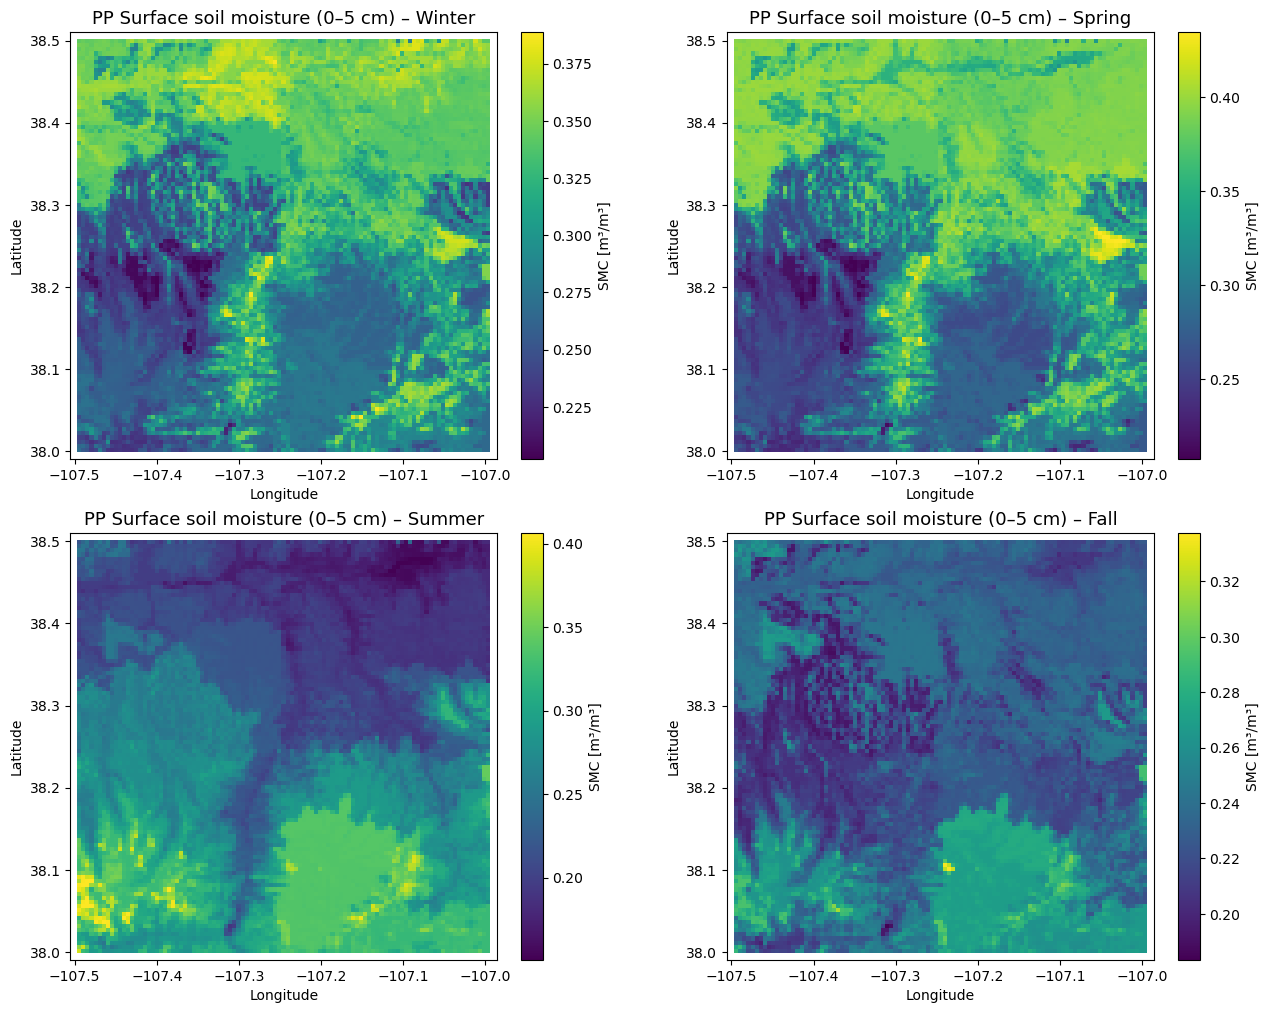

In [2]:
import os
import glob
import numpy as np
import netCDF4 as nc
import pandas as pd
import matplotlib.pyplot as plt

# Path

path = "/scratch/alpine/battobrah@xsede.org/Rice_NMT_Snow/upper_colorado_test025/experiments/simulations/MSWX_3h_Snow_Project3_pp_upper_colorado_test025_11yrs_100hru_100bh_test_new_test_domain/"

outputdir = "/scratch/alpine/battobrah@xsede.org/HydroBlocks_Enrico_dev/output_plots"
os.makedirs(outputdir, exist_ok=True)

output_dir = path + "postprocess/output_dir/"
files = sorted(glob.glob(output_dir + "*.nc"))

print("Number of files:", len(files))
print("First file:", files[0])
print("Last file:", files[-1])

# select variables
varname = "smc"

#Period
year_start = 2014
year_end = 2024

seasons = ["Winter", "Spring", "Summer", "Fall"]
season_months = {"Winter": [12, 1, 2], "Spring": [3, 4, 5], "Summer": [6, 7, 8],"Fall": [9, 10, 11],}

# Read cordinates
with nc.Dataset(files[0]) as fp:
    lon = np.array(fp.variables["lon"][:])
    lat = np.array(fp.variables["lat"][:])

# Figure
fig, axes = plt.subplots(2, 2, figsize=(13, 10), constrained_layout=True)

axes = axes.flatten()
fig.patch.set_facecolor("white")

# loop over all 4 seasons
for ax, season in zip(axes, seasons):
    months = season_months[season]
    print(f"\nCreating plot for {season}")
    
    season_files = []
    for f in files:
        fname = os.path.basename(f).replace(".nc", "")
        date = pd.to_datetime(fname, format="%Y%m%d")

        if year_start <= date.year <= year_end and date.month in months:
            season_files.append(f)
        #if date.month in months:
         #   season_files.append(f)

    print(f"{season} files:", len(season_files))

    sum_map = None          # placeholders for shapes (stores the running sum of all valid values at each grid cell)
    count_map = None        # keeps track of how many valid values have been added at each grid cell

    for i, f in enumerate(season_files):

        if i % 500 == 0:
            print(f"  {season}: {i+1}/{len(season_files)} {os.path.basename(f)}")

        with nc.Dataset(f) as fp:
            data = np.array(fp.variables[varname][:], dtype=np.float32)

        data[data <= -9990] = np.nan

        # Daily mean from 8 three-hourly outputs
        if data.ndim == 3:
            data = np.nanmean(data, axis=0)

        if sum_map is None:
            sum_map = np.zeros_like(data, dtype=np.float32)
            count_map = np.zeros_like(data, dtype=np.float32)

        valid = np.isfinite(data)

        sum_map[valid] += data[valid]
        count_map[valid] += 1

    # Seasonal mean
    season_mean = np.divide(
        sum_map,
        count_map,
        out=np.full_like(sum_map, np.nan, dtype=np.float32),
        where=count_map > 0
    )

    season_mean = np.ma.masked_invalid(season_mean)

    plot_data = season_mean

    valid = np.isfinite(season_mean)
    rows, cols = np.where(valid)

    xmin = lon[cols.min()]
    xmax = lon[cols.max()]
    ymin = lat[rows.min()]
    ymax = lat[rows.max()]

    pad_x = 0.02 * (xmax - xmin)
    pad_y = 0.02 * (ymax - ymin)

    ax.set_facecolor("white")

    im = ax.imshow(
        plot_data,
        origin="lower",
        extent=[lon.min(), lon.max(), lat.min(), lat.max()],
        cmap="viridis",
        interpolation="nearest"
    )

    ax.set_xlim(xmin - pad_x, xmax + pad_x)
    ax.set_ylim(ymin - pad_y, ymax + pad_y)

    ax.set_title(f"PP Surface soil moisture (0–5 cm) – {season}", fontsize=13)
    ax.set_xlabel("Longitude")
    ax.set_ylabel("Latitude")

    cbar = fig.colorbar(
        im,
        ax=ax,
        label="SMC [m³/m³]",
        fraction=0.046,
        pad=0.02
    )

    cbar.outline.set_linewidth(0.8)

# Save
outfile = os.path.join(outputdir,f"PP_smc_surface_seasonal_mean_postprocess_tight_{year_start}_{year_end}_dailymean.png")

plt.savefig(outfile, dpi=300, bbox_inches="tight", facecolor="white")
print("\nSaved:", outfile)

plt.show()

In [12]:
import geospatialtools.gdal_tools as gdal_tools
import numpy as np

hrus_file = path + "postprocess/hrus.vrt"

meta = gdal_tools.retrieve_metadata(hrus_file)

print("Number of columns:", meta["nx"])
print("Number of rows   :", meta["ny"])

print("xmin:", meta["minx"])
print("xmax:", meta["maxx"])
print("ymin:", meta["miny"])
print("ymax:", meta["maxy"])

dx = (meta["maxx"] - meta["minx"]) / meta["nx"]
dy = (meta["maxy"] - meta["miny"]) / meta["ny"]

print("\nGrid spacing:")
print("Longitude:", dx, "degrees")
print("Latitude :", dy, "degrees")

Number of columns: 1201
Number of rows   : 1201
xmin: -107.7504166666655
xmax: -106.74958333333221
ymin: 37.74958333333264
ymax: 38.75041666666593

Grid spacing:
Longitude: 0.0008333333333332972 degrees
Latitude : 0.0008333333333332972 degrees


Number of files: 4015
First file: /scratch/alpine/battobrah@xsede.org/Rice_NMT_Snow/upper_colorado_test025/experiments/simulations/MSWX_3h_Snow_Project3_pp_upper_colorado_test025_11yrs_100hru_100bh_test_new_test_domain/postprocess/output_dir/20140101.nc
Last file: /scratch/alpine/battobrah@xsede.org/Rice_NMT_Snow/upper_colorado_test025/experiments/simulations/MSWX_3h_Snow_Project3_pp_upper_colorado_test025_11yrs_100hru_100bh_test_new_test_domain/postprocess/output_dir/20241228.nc

Creating plot for Winter
Winter files: 990
  Winter: 1/990 20140101.nc


/projects/battobrah@xsede.org/code-server/tmp/ipykernel_4135464/675623697.py:75: RuntimeWarning: Mean of empty slice
  data = np.nanmean(data, axis=0)


  Winter: 501/990 20190219.nc

Creating plot for Spring
Spring files: 1012
  Spring: 1/1012 20140301.nc
  Spring: 501/1012 20190410.nc
  Spring: 1001/1012 20240520.nc

Creating plot for Summer
Summer files: 1012
  Summer: 1/1012 20140601.nc
  Summer: 501/1012 20190711.nc
  Summer: 1001/1012 20240820.nc

Creating plot for Fall
Fall files: 1001
  Fall: 1/1001 20140901.nc
  Fall: 501/1001 20191016.nc
  Fall: 1001/1001 20241130.nc

Saved: /scratch/alpine/battobrah@xsede.org/HydroBlocks_Enrico_dev/output_plots/5km_PP_smc_surface_seasonal_mean_postprocess_tight_2014_2024_dailymean.png


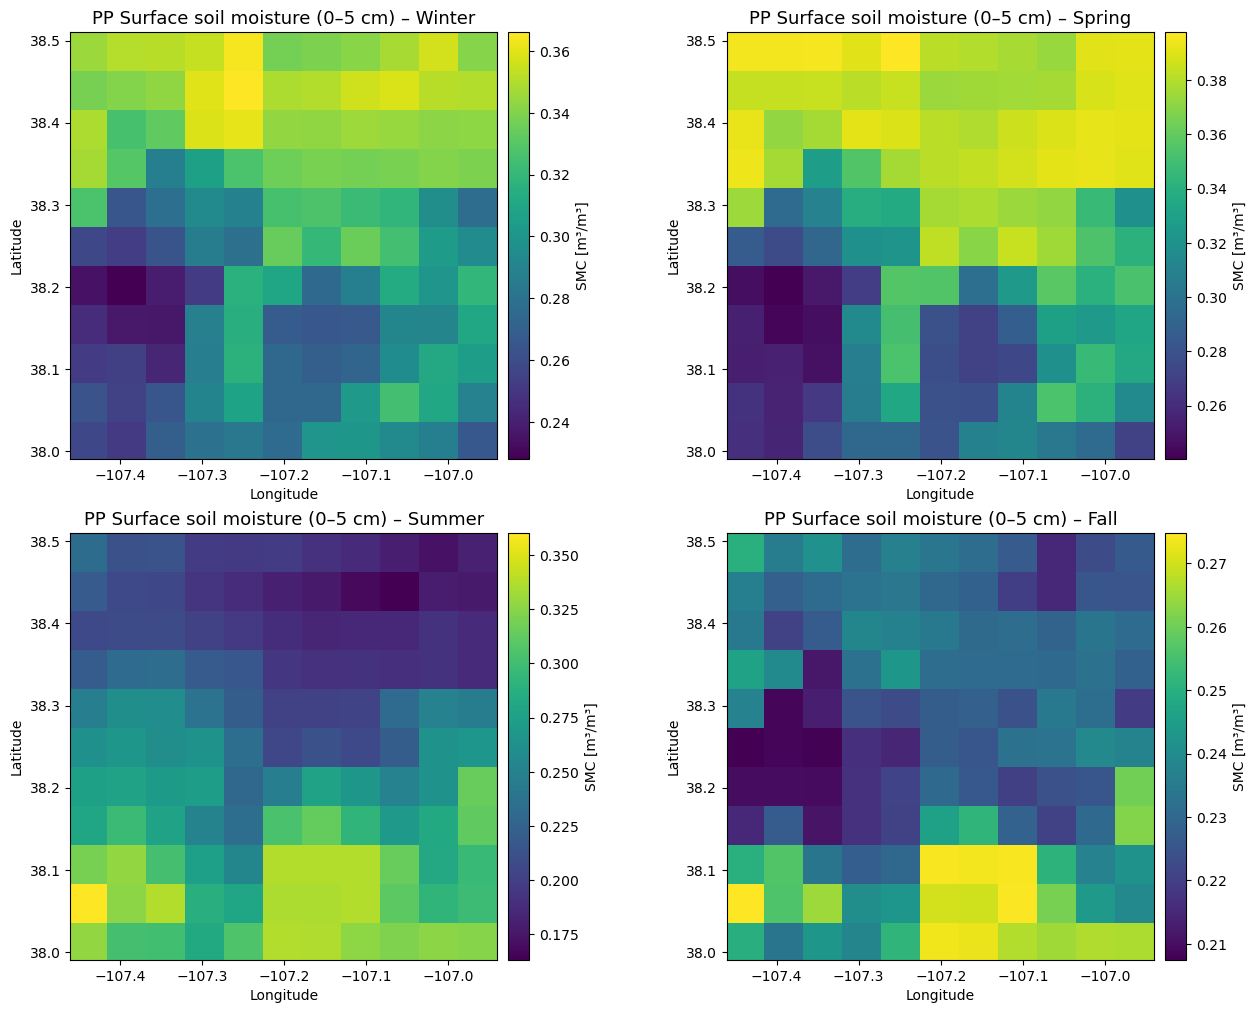

In [5]:
import os
import glob
import numpy as np
import netCDF4 as nc
import pandas as pd
import matplotlib.pyplot as plt

# Path

path = "/scratch/alpine/battobrah@xsede.org/Rice_NMT_Snow/upper_colorado_test025/experiments/simulations/MSWX_3h_Snow_Project3_pp_upper_colorado_test025_11yrs_100hru_100bh_test_new_test_domain/"

outputdir = "/scratch/alpine/battobrah@xsede.org/HydroBlocks_Enrico_dev/output_plots"
os.makedirs(outputdir, exist_ok=True)

output_dir = path + "postprocess/output_dir/"
files = sorted(glob.glob(output_dir + "*.nc"))

print("Number of files:", len(files))
print("First file:", files[0])
print("Last file:", files[-1])

# select variables
varname = "smc"

#Period
year_start = 2014
year_end = 2024

seasons = ["Winter", "Spring", "Summer", "Fall"]
season_months = {"Winter": [12, 1, 2], "Spring": [3, 4, 5], "Summer": [6, 7, 8],"Fall": [9, 10, 11],}

# Read cordinates
with nc.Dataset(files[0]) as fp:
    lon = np.array(fp.variables["lon"][:])
    lat = np.array(fp.variables["lat"][:])

# Figure
fig, axes = plt.subplots(2, 2, figsize=(13, 10), constrained_layout=True)

axes = axes.flatten()
fig.patch.set_facecolor("white")

# loop over seasons
for ax, season in zip(axes, seasons):
    months = season_months[season]
    print(f"\nCreating plot for {season}")
    
    season_files = []
    for f in files:
        fname = os.path.basename(f).replace(".nc", "")
        date = pd.to_datetime(fname, format="%Y%m%d")

        if year_start <= date.year <= year_end and date.month in months:
            season_files.append(f)
        #if date.month in months:
         #   season_files.append(f)

    print(f"{season} files:", len(season_files))

    sum_map = None
    count_map = None

    for i, f in enumerate(season_files):

        if i % 500 == 0:
            print(f"  {season}: {i+1}/{len(season_files)} {os.path.basename(f)}")

        with nc.Dataset(f) as fp:
            data = np.array(fp.variables[varname][:], dtype=np.float32)

        data[data <= -9990] = np.nan

        # Daily mean from 8 three-hourly outputs
        if data.ndim == 3:
            data = np.nanmean(data, axis=0)

        if sum_map is None:
            sum_map = np.zeros_like(data, dtype=np.float32)
            count_map = np.zeros_like(data, dtype=np.float32)

        valid = np.isfinite(data)

        sum_map[valid] += data[valid]
        count_map[valid] += 1

    # Seasonal mean
    season_mean = np.divide(
        sum_map,
        count_map,
        out=np.full_like(sum_map, np.nan, dtype=np.float32),
        where=count_map > 0
    )

    season_mean = np.ma.masked_invalid(season_mean)

    plot_data = season_mean

    valid = np.isfinite(season_mean)
    rows, cols = np.where(valid)

    xmin = lon[cols.min()]
    xmax = lon[cols.max()]
    ymin = lat[rows.min()]
    ymax = lat[rows.max()]

    pad_x = 0.02 * (xmax - xmin)
    pad_y = 0.02 * (ymax - ymin)

    ax.set_facecolor("white")

    im = ax.imshow(
        plot_data,
        origin="lower",
        extent=[lon.min(), lon.max(), lat.min(), lat.max()],
        cmap="viridis",
        interpolation="nearest"
    )

    ax.set_xlim(xmin - pad_x, xmax + pad_x)
    ax.set_ylim(ymin - pad_y, ymax + pad_y)

    ax.set_title(f"PP Surface soil moisture (0–5 cm) – {season}", fontsize=13)
    ax.set_xlabel("Longitude")
    ax.set_ylabel("Latitude")

    cbar = fig.colorbar(
        im,
        ax=ax,
        label="SMC [m³/m³]",
        fraction=0.046,
        pad=0.02
    )

    cbar.outline.set_linewidth(0.8)

# Save
outfile = os.path.join(outputdir,f"5km_PP_smc_surface_seasonal_mean_postprocess_tight_{year_start}_{year_end}_dailymean.png")

plt.savefig(outfile, dpi=300, bbox_inches="tight", facecolor="white")
print("\nSaved:", outfile)

plt.show()

In [3]:
# ============================================================
# GRID RESOLUTION
# ============================================================

dx = np.mean(np.diff(lon))
dy = np.mean(np.diff(lat))

print(f"Longitude range : {lon.min():.6f} to {lon.max():.6f}")
print(f"Latitude range  : {lat.min():.6f} to {lat.max():.6f}")

print(f"Longitude spacing : {dx:.12f} degrees")
print(f"Latitude spacing  : {dy:.12f} degrees")

# Approximate spacing in meters
lat0 = np.mean(lat)

dx_m = dx * 111320 * np.cos(np.deg2rad(lat0))
dy_m = dy * 111320

print(f"Approximate resolution:")
print(f"  East-West : {dx_m:.1f} m")
print(f"  North-South: {dy_m:.1f} m")

print(f"Grid size: {len(lon)} × {len(lat)}")

Longitude range : -107.700417 to -106.750417
Latitude range  : 37.750417 to 38.700417
Longitude spacing : 0.050000000000 degrees
Latitude spacing  : 0.050000000000 degrees
Approximate resolution:
  East-West : 4372.6 m
  North-South: 5566.0 m
Grid size: 20 × 20
